# 자치구 간 이동 상세 분석

## 1. 데이터 로드

정제된 탑승내역 데이터를 불러온다. 노트북 실행 위치가 프로젝트 루트이거나 `notebooks_kms/` 내부인 경우 모두 동작하도록 프로젝트 루트와 데이터 경로를 설정한다.


In [1]:
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

boarding_path = PROCESSED_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
print(boarding_path)

df = pd.read_csv(boarding_path)
print(f"전체 행 수: {len(df):,}")
display(df.head())


c:\Users\young\my_project\260901_call_taxi_DA\data\processed\서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv
전체 행 수: 1,722,490


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


## 2. 탑승완료 필터링

이동 흐름 분석은 실제 승차와 하차가 완료된 건을 기준으로 한다. `승차일시`와 `하차일시`가 있고 `취소일시`가 없는 행만 탑승완료 데이터로 분리한다.


In [2]:
completed = df[
    df["승차일시"].notna()
    & df["하차일시"].notna()
    & df["취소일시"].isna()
].copy()

print(f"탑승완료 건수: {len(completed):,} / 전체 {len(df):,} ({len(completed) / len(df) * 100:.1f}%)")
display(completed.head())


탑승완료 건수: 1,477,067 / 전체 1,722,490 (85.8%)


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체
5,2025-01-01 00:05:54.000,2025-01-01 00:06:00.000,2025-01-01 00:16:19.457,2025-01-01 00:54:19.940,2025-01-01 01:11:02.643,NaN,서초구,서초3동,서초구,반포2동,귀가,1700.0,5205,특장차,뇌병


## 3. 서울 25개구 필터링

서울 자치구 내 이동만 분석하기 위해 출발구와 목적구가 모두 서울 25개 자치구에 포함되는 탑승완료 건을 분리한다.


In [3]:
SEOUL_25 = [
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
]

seoul_completed = completed[
    completed["출발구"].isin(SEOUL_25)
    & completed["목적구"].isin(SEOUL_25)
].copy()

print(f"서울 25개구 내 탑승완료 건수: {len(seoul_completed):,}")
print(f"전체 탑승완료 대비 비율: {len(seoul_completed) / len(completed) * 100:.1f}%")
print(f"집계 출발구 수: {seoul_completed['출발구'].nunique():,}개")
print(f"집계 목적구 수: {seoul_completed['목적구'].nunique():,}개")


서울 25개구 내 탑승완료 건수: 1,362,668
전체 탑승완료 대비 비율: 92.3%
집계 출발구 수: 25개
집계 목적구 수: 25개


## 4. 구 간 이동 추출

`출발구`와 `목적구`가 다른 행만 추출한다.  
이 데이터는 서울 25개 자치구 안에서 서로 다른 자치구 사이에 발생한 탑승완료 이동을 의미한다.

In [4]:
diff_gu_seoul = seoul_completed[
    seoul_completed["출발구"] != seoul_completed["목적구"]
].copy()

same_gu_seoul = seoul_completed[
    seoul_completed["출발구"] == seoul_completed["목적구"]
].copy()

print(f"서울→서울 탑승완료 건수: {len(seoul_completed):,}")
print(f"구 간 이동 건수: {len(diff_gu_seoul):,} ({len(diff_gu_seoul) / len(seoul_completed) * 100:.1f}%)")
print(f"같은 구 내 이동 건수: {len(same_gu_seoul):,} ({len(same_gu_seoul) / len(seoul_completed) * 100:.1f}%)")

display(diff_gu_seoul.head())

서울→서울 탑승완료 건수: 1,362,668
구 간 이동 건수: 836,563 (61.4%)
같은 구 내 이동 건수: 526,105 (38.6%)


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체
6,2025-01-01 00:06:14.357,2025-01-01 00:06:14.357,2025-01-01 00:41:09.387,2025-01-01 01:23:04.807,2025-01-01 01:56:38.873,NaN,관악구,삼성동,서초구,양재1동,기타,3100.0,13704,특장차,지체
7,2025-01-01 00:07:39.053,2025-01-01 00:07:39.053,2025-01-01 01:49:24.407,2025-01-01 02:17:58.340,2025-01-01 02:39:26.440,NaN,은평구,역촌동,강서구,가양제3동,기타,2600.0,8799,특장차,지체


## 출발지별 목적지 집중도 분석

각 `출발구`에서 다른 자치구로 이동한 탑승완료 건이 특정 `목적구`에 얼마나 집중되는지 확인한다.  
이를 통해 특정 출발구에서 반복적으로 향하는 대표 목적지가 있는지, 또는 여러 목적지로 분산되는지를 파악한다.

`TOP1 목적지 비율`이 높으면 특정 목적구로 이동이 쏠리는 출발구로 볼 수 있고, `TOP3 목적지 비율`이 높으면 소수 목적지를 중심으로 이동이 반복되는 지역으로 해석할 수 있다.

In [5]:
if "diff_gu_seoul" not in globals():
    diff_gu_seoul = seoul_completed[
        seoul_completed["출발구"] != seoul_completed["목적구"]
    ].copy()

print(f"구 간 이동 건수: {len(diff_gu_seoul):,}")
print(f"출발구 수: {diff_gu_seoul['출발구'].nunique():,}개")
print(f"목적구 수: {diff_gu_seoul['목적구'].nunique():,}개")

print(
    "같은 구 이동 포함 여부:",
    (diff_gu_seoul["출발구"] == diff_gu_seoul["목적구"]).sum(),
    "건",
)

display(diff_gu_seoul.head())

구 간 이동 건수: 836,563
출발구 수: 25개
목적구 수: 25개
같은 구 이동 포함 여부: 0 건


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체
6,2025-01-01 00:06:14.357,2025-01-01 00:06:14.357,2025-01-01 00:41:09.387,2025-01-01 01:23:04.807,2025-01-01 01:56:38.873,NaN,관악구,삼성동,서초구,양재1동,기타,3100.0,13704,특장차,지체
7,2025-01-01 00:07:39.053,2025-01-01 00:07:39.053,2025-01-01 01:49:24.407,2025-01-01 02:17:58.340,2025-01-01 02:39:26.440,NaN,은평구,역촌동,강서구,가양제3동,기타,2600.0,8799,특장차,지체


## 출발구-목적구별 이동건수 집계

구 간 이동 데이터에서 `출발구`와 `목적구` 조합별 이동건수를 집계한다.  
이 표는 이후 출발구별 목적지 순위와 목적지 집중도 비율을 계산하는 기본 데이터로 사용한다.

In [6]:
origin_destination_count = (
    diff_gu_seoul
    .groupby(["출발구", "목적구"])
    .size()
    .reset_index(name="이동건수")
    .sort_values(["출발구", "이동건수"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"출발구-목적구 조합 수: {len(origin_destination_count):,}개")

display(origin_destination_count.head(30))

출발구-목적구 조합 수: 600개


,출발구,목적구,이동건수
0,강남구,송파구,6790
1,강남구,서초구,5016
2,강남구,강동구,2579
3,강남구,광진구,1504
4,강남구,노원구,1340
5,강남구,성동구,1285
6,강남구,중랑구,1093
7,강남구,동대문구,1085
8,강남구,서대문구,1007
9,강남구,중구,945


## 출발구-목적구 이동건수 히트맵

`출발구`를 행, `목적구`를 열로 두고 자치구 간 이동건수를 히트맵으로 시각화한다.  
각 칸의 숫자는 해당 출발구에서 목적구로 이동한 탑승완료 건수를 의미한다.  
색이 진할수록 이동건수가 많아 특정 출발지-목적지 조합의 이동 집중도를 확인할 수 있다.

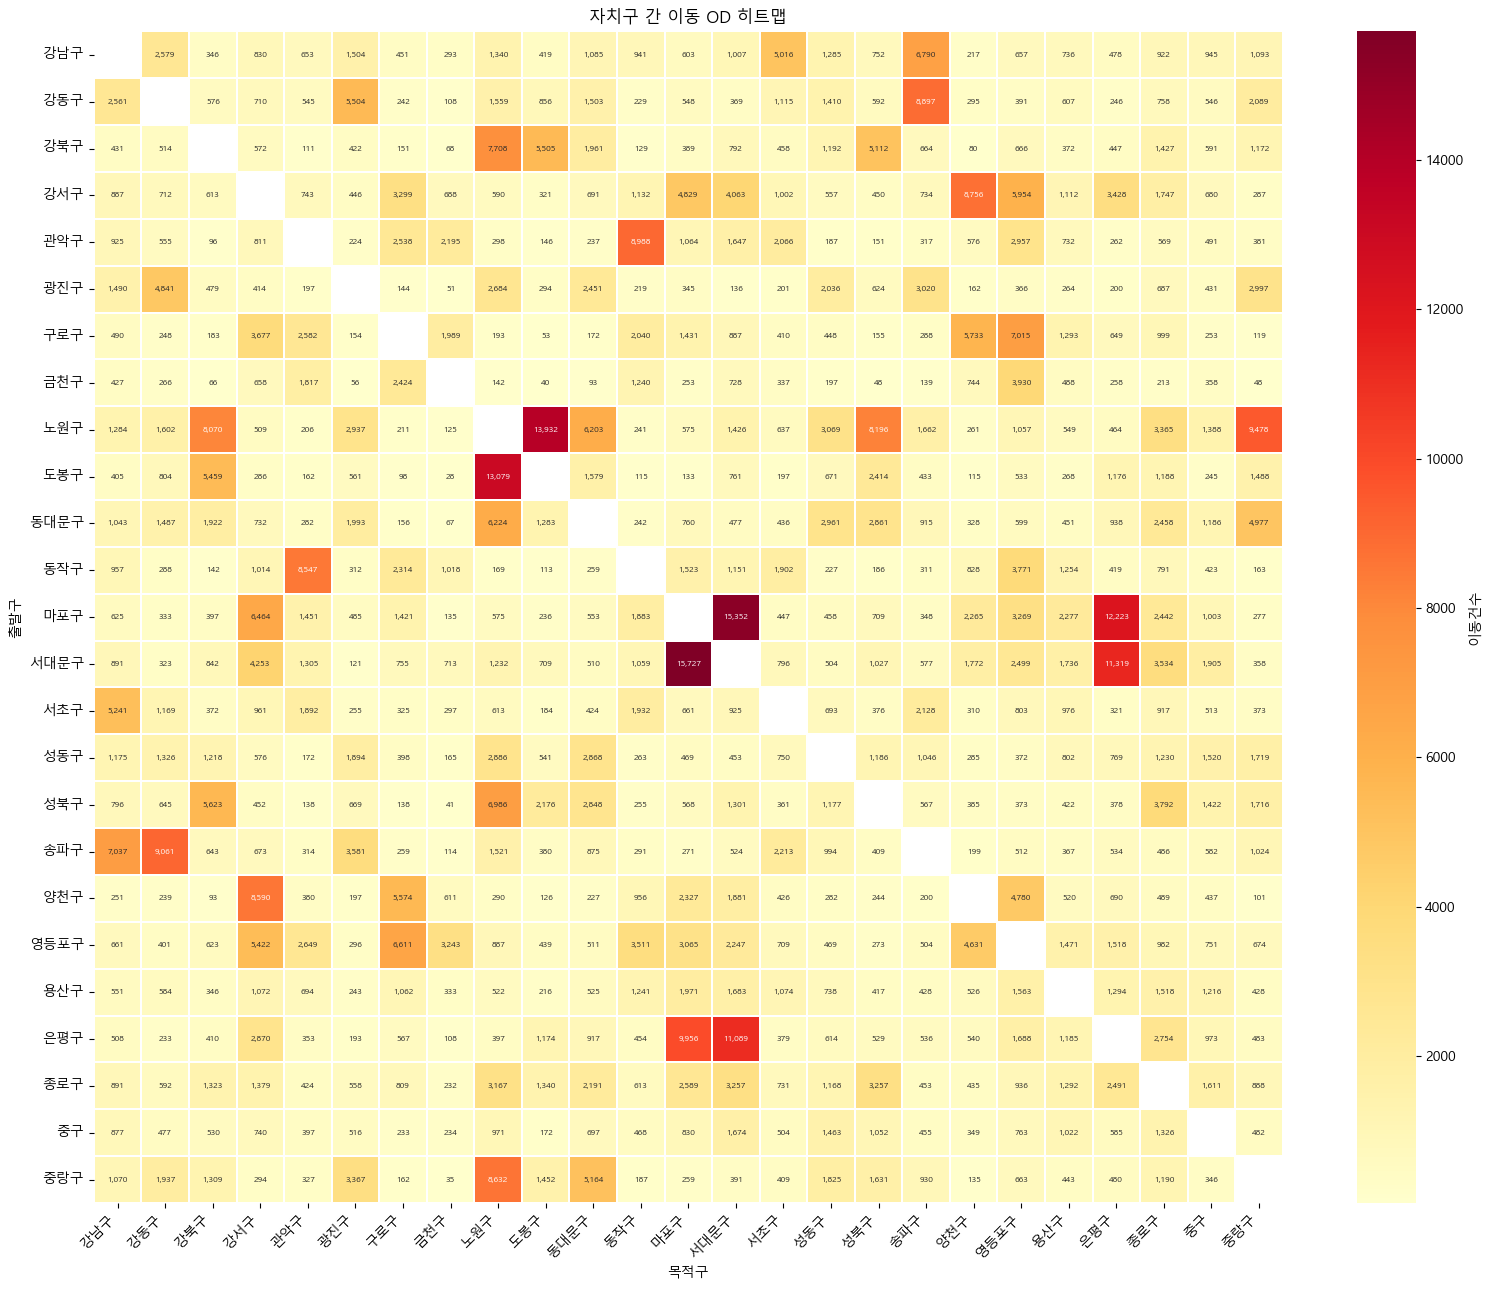

In [7]:
od_pivot = (
    origin_destination_count
    .pivot(index="출발구", columns="목적구", values="이동건수")
    .reindex(index=SEOUL_25, columns=SEOUL_25, fill_value=0)
)

plt.figure(figsize=(16, 13))

sns.heatmap(
    od_pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=True,
    fmt=",.0f",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "이동건수"},
)

plt.title("자치구 간 이동 OD 히트맵")
plt.xlabel("목적구")
plt.ylabel("출발구")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 출발구별 목적지 순위 및 비율 계산

각 `출발구` 안에서 목적구별 이동건수가 차지하는 비율을 계산한다.  
이를 통해 특정 출발구의 이동이 하나의 목적구에 집중되는지, 여러 목적구로 분산되는지 확인할 수 있다.

In [8]:
origin_total_count = (
    origin_destination_count
    .groupby("출발구")["이동건수"]
    .sum()
    .rename("출발구_전체이동건수")
    .reset_index()
)

origin_destination_ratio = origin_destination_count.merge(
    origin_total_count,
    on="출발구",
    how="left",
)

origin_destination_ratio["출발구내_목적지비율(%)"] = (
    origin_destination_ratio["이동건수"]
    / origin_destination_ratio["출발구_전체이동건수"]
    * 100
).round(2)

origin_destination_ratio["목적지순위"] = (
    origin_destination_ratio
    .groupby("출발구")["이동건수"]
    .rank(method="first", ascending=False)
    .astype(int)
)

origin_destination_ratio = origin_destination_ratio.sort_values(
    ["출발구", "목적지순위"]
).reset_index(drop=True)

display(origin_destination_ratio.head(50))

,출발구,목적구,이동건수,출발구_전체이동건수,출발구내_목적지비율(%),목적지순위
0,강남구,송파구,6790,30942,21.94,1
1,강남구,서초구,5016,30942,16.21,2
2,강남구,강동구,2579,30942,8.33,3
3,강남구,광진구,1504,30942,4.86,4
4,강남구,노원구,1340,30942,4.33,5
5,강남구,성동구,1285,30942,4.15,6
6,강남구,중랑구,1093,30942,3.53,7
7,강남구,동대문구,1085,30942,3.51,8
8,강남구,서대문구,1007,30942,3.25,9
9,강남구,중구,945,30942,3.05,10


## 출발구별 상위 5개 목적구 확인

각 `출발구`에서 이동건수가 많은 `목적구` 상위 5개를 확인한다.  
이를 통해 자치구별로 반복적으로 향하는 대표 목적지가 있는지, 또는 이동이 여러 지역으로 분산되는지 살펴볼 수 있다.

In [9]:
top5_destinations_by_origin = (
    origin_destination_ratio
    .sort_values(["출발구", "목적지순위"])
    .groupby("출발구")
    .head(5)
    .reset_index(drop=True)
)

display(top5_destinations_by_origin)

,출발구,목적구,이동건수,출발구_전체이동건수,출발구내_목적지비율(%),목적지순위
0,강남구,송파구,6790,30942,21.94,1
1,강남구,서초구,5016,30942,16.21,2
2,강남구,강동구,2579,30942,8.33,3
3,강남구,광진구,1504,30942,4.86,4
4,강남구,노원구,1340,30942,4.33,5
...,...,...,...,...,...,...
120,중랑구,노원구,8632,32638,26.45,1
121,중랑구,동대문구,5164,32638,15.82,2
122,중랑구,광진구,3367,32638,10.32,3
123,중랑구,강동구,1937,32638,5.93,4


In [10]:
for origin in SEOUL_25:
    origin_top5 = top5_destinations_by_origin[
        top5_destinations_by_origin["출발구"] == origin
    ]

    if len(origin_top5) == 0:
        continue

    print(f"\n=== {origin} 출발 TOP 5 목적구 ===")
    display(
        origin_top5[
            [
                "목적지순위",
                "목적구",
                "이동건수",
                "출발구_전체이동건수",
                "출발구내_목적지비율(%)",
            ]
        ]
    )


=== 강남구 출발 TOP 5 목적구 ===


,목적지순위,목적구,이동건수,출발구_전체이동건수,출발구내_목적지비율(%)
0,1,송파구,6790,30942,21.94
1,2,서초구,5016,30942,16.21
2,3,강동구,2579,30942,8.33
3,4,광진구,1504,30942,4.86
4,5,노원구,1340,30942,4.33



=== 강동구 출발 TOP 5 목적구 ===


,목적지순위,목적구,이동건수,출발구_전체이동건수,출발구내_목적지비율(%)
5,1,송파구,8897,32256,27.58
6,2,광진구,5504,32256,17.06
7,3,강남구,2561,32256,7.94
8,4,중랑구,2089,32256,6.48
9,5,노원구,1559,32256,4.83



=== 강북구 출발 TOP 5 목적구 ===


...

,목적지순위,목적구,이동건수,출발구_전체이동건수,출발구내_목적지비율(%)
110,1,서대문구,3257,32627,9.98
111,2,성북구,3257,32627,9.98
112,3,노원구,3167,32627,9.71
113,4,마포구,2589,32627,7.94
114,5,은평구,2491,32627,7.63



=== 중구 출발 TOP 5 목적구 ===


,목적지순위,목적구,이동건수,출발구_전체이동건수,출발구내_목적지비율(%)
115,1,서대문구,1674,16817,9.95
116,2,성동구,1463,16817,8.70
117,3,종로구,1326,16817,7.88
118,4,성북구,1052,16817,6.26
119,5,용산구,1022,16817,6.08



=== 중랑구 출발 TOP 5 목적구 ===


,목적지순위,목적구,이동건수,출발구_전체이동건수,출발구내_목적지비율(%)
120,1,노원구,8632,32638,26.45
121,2,동대문구,5164,32638,15.82
122,3,광진구,3367,32638,10.32
123,4,강동구,1937,32638,5.93
124,5,성동구,1825,32638,5.59


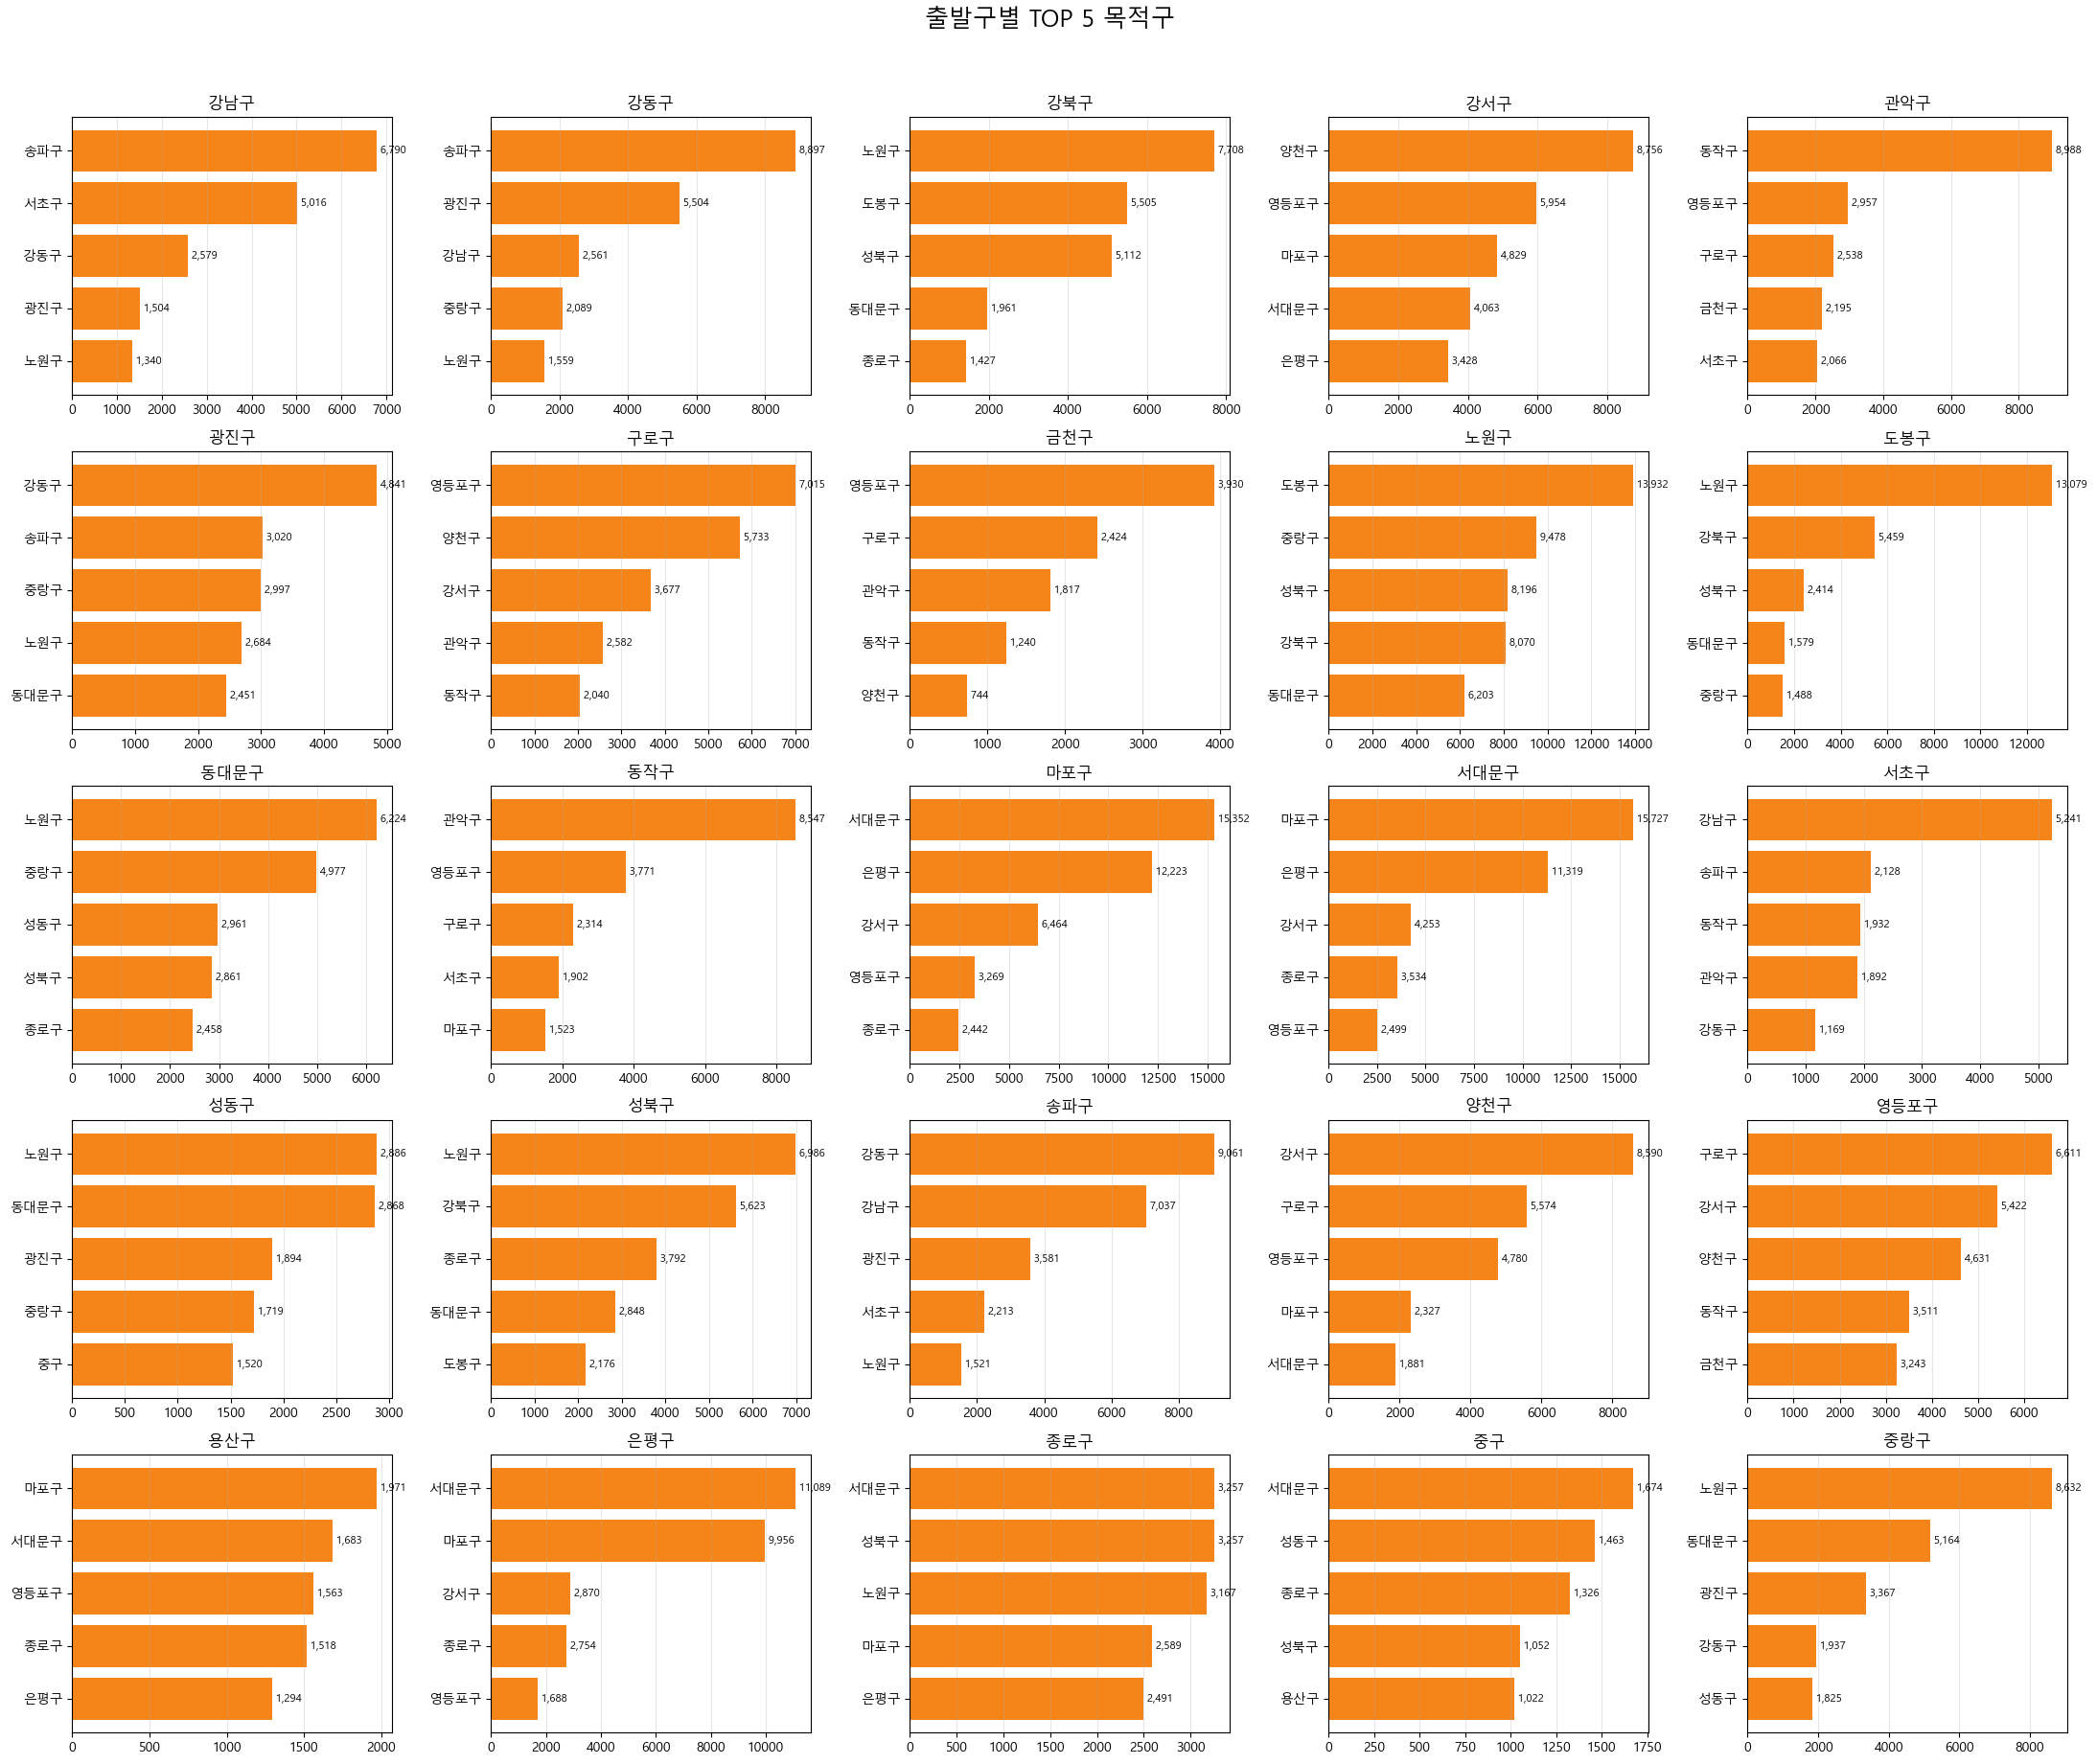

: 

In [ ]:
top5_destinations_by_origin = (
    origin_destination_ratio
    .sort_values(["출발구", "목적지순위"])
    .groupby("출발구")
    .head(5)
    .reset_index(drop=True)
)

n_cols = 5
n_rows = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 18), sharex=False)
axes = axes.flatten()

for idx, origin in enumerate(SEOUL_25):
    ax = axes[idx]

    plot_data = top5_destinations_by_origin[
        top5_destinations_by_origin["출발구"] == origin
    ].sort_values("이동건수", ascending=True)

    ax.barh(plot_data["목적구"], plot_data["이동건수"], color="#f58518")
    ax.set_title(origin)
    ax.grid(axis="x", alpha=0.3)

    for index, value in enumerate(plot_data["이동건수"]):
        ax.text(value, index, f" {value:,.0f}", va="center", fontsize=8)

for ax in axes[len(SEOUL_25):]:
    ax.axis("off")

fig.suptitle("출발구별 TOP 5 목적구", fontsize=18, y=1.02)

plt.tight_layout()
plt.show()